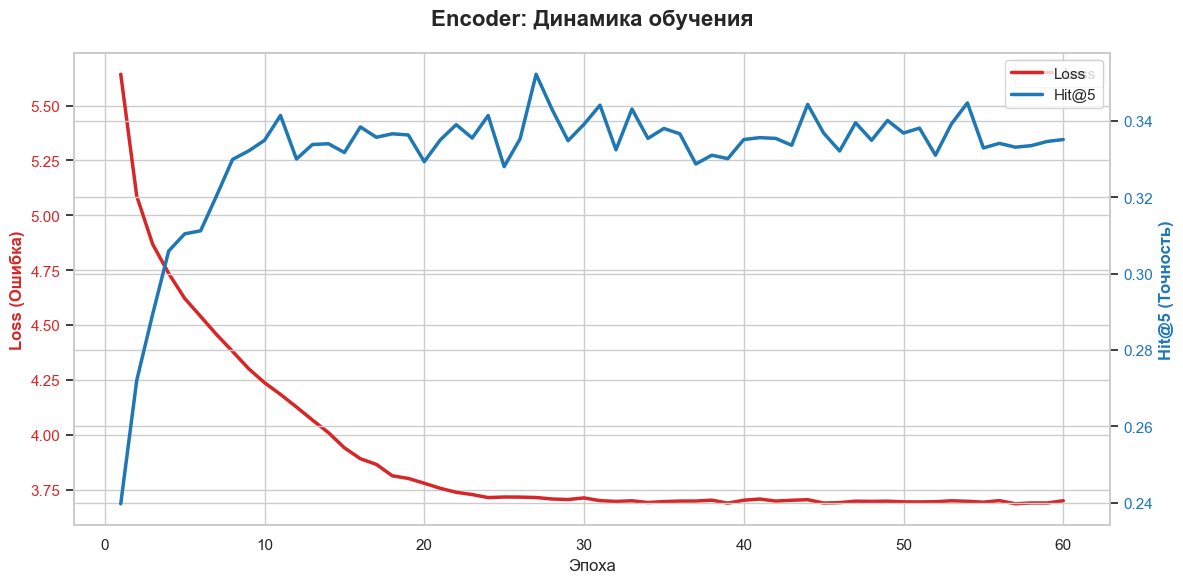

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# Твои данные из логов
raw_logs = """
Эпоха 1 | Loss: 5.6429 | 📊 Hit@5: 0.2397 | LR: 0.000100
Эпоха 2 | Loss: 5.0878 | 📊 Hit@5: 0.2720 | LR: 0.000100
Эпоха 3 | Loss: 4.8678 | 📊 Hit@5: 0.2894 | LR: 0.000100
Эпоха 4 | Loss: 4.7352 | 📊 Hit@5: 0.3059 | LR: 0.000100
Эпоха 5 | Loss: 4.6216 | 📊 Hit@5: 0.3104 | LR: 0.000100
Эпоха 6 | Loss: 4.5390 | 📊 Hit@5: 0.3112 | LR: 0.000100
Эпоха 7 | Loss: 4.4562 | 📊 Hit@5: 0.3204 | LR: 0.000100
Эпоха 8 | Loss: 4.3797 | 📊 Hit@5: 0.3299 | LR: 0.000100
Эпоха 9 | Loss: 4.3013 | 📊 Hit@5: 0.3321 | LR: 0.000100
Эпоха 10 | Loss: 4.2370 | 📊 Hit@5: 0.3349 | LR: 0.000100
Эпоха 11 | Loss: 4.1836 | 📊 Hit@5: 0.3414 | LR: 0.000100
Эпоха 12 | Loss: 4.1262 | 📊 Hit@5: 0.3300 | LR: 0.000100
Эпоха 13 | Loss: 4.0667 | 📊 Hit@5: 0.3338 | LR: 0.000100
Эпоха 14 | Loss: 4.0094 | 📊 Hit@5: 0.3340 | LR: 0.000050
Эпоха 15 | Loss: 3.9402 | 📊 Hit@5: 0.3317 | LR: 0.000050
Эпоха 16 | Loss: 3.8905 | 📊 Hit@5: 0.3384 | LR: 0.000050
Эпоха 17 | Loss: 3.8646 | 📊 Hit@5: 0.3357 | LR: 0.000025
Эпоха 18 | Loss: 3.8126 | 📊 Hit@5: 0.3366 | LR: 0.000025
Эпоха 19 | Loss: 3.8006 | 📊 Hit@5: 0.3363 | LR: 0.000025
Эпоха 20 | Loss: 3.7786 | 📊 Hit@5: 0.3293 | LR: 0.000013
Эпоха 21 | Loss: 3.7557 | 📊 Hit@5: 0.3350 | LR: 0.000013
Эпоха 22 | Loss: 3.7374 | 📊 Hit@5: 0.3390 | LR: 0.000013
Эпоха 23 | Loss: 3.7272 | 📊 Hit@5: 0.3355 | LR: 0.000006
Эпоха 24 | Loss: 3.7133 | 📊 Hit@5: 0.3414 | LR: 0.000006
Эпоха 25 | Loss: 3.7159 | 📊 Hit@5: 0.3280 | LR: 0.000006
Эпоха 26 | Loss: 3.7155 | 📊 Hit@5: 0.3353 | LR: 0.000003
Эпоха 27 | Loss: 3.7136 | 📊 Hit@5: 0.3522 | LR: 0.000003
Эпоха 28 | Loss: 3.7069 | 📊 Hit@5: 0.3430 | LR: 0.000003
Эпоха 29 | Loss: 3.7045 | 📊 Hit@5: 0.3348 | LR: 0.000003
Эпоха 30 | Loss: 3.7118 | 📊 Hit@5: 0.3391 | LR: 0.000002
Эпоха 31 | Loss: 3.6994 | 📊 Hit@5: 0.3441 | LR: 0.000002
Эпоха 32 | Loss: 3.6958 | 📊 Hit@5: 0.3324 | LR: 0.000002
Эпоха 33 | Loss: 3.6987 | 📊 Hit@5: 0.3431 | LR: 0.000001
Эпоха 34 | Loss: 3.6908 | 📊 Hit@5: 0.3354 | LR: 0.000001
Эпоха 35 | Loss: 3.6951 | 📊 Hit@5: 0.3380 | LR: 0.000001
Эпоха 36 | Loss: 3.6973 | 📊 Hit@5: 0.3366 | LR: 0.000000
Эпоха 37 | Loss: 3.6975 | 📊 Hit@5: 0.3287 | LR: 0.000000
Эпоха 38 | Loss: 3.7015 | 📊 Hit@5: 0.3310 | LR: 0.000000
Эпоха 39 | Loss: 3.6881 | 📊 Hit@5: 0.3301 | LR: 0.000000
Эпоха 40 | Loss: 3.7013 | 📊 Hit@5: 0.3351 | LR: 0.000000
Эпоха 41 | Loss: 3.7067 | 📊 Hit@5: 0.3356 | LR: 0.000000
Эпоха 42 | Loss: 3.6974 | 📊 Hit@5: 0.3354 | LR: 0.000000
Эпоха 43 | Loss: 3.7011 | 📊 Hit@5: 0.3336 | LR: 0.000000
Эпоха 44 | Loss: 3.7037 | 📊 Hit@5: 0.3443 | LR: 0.000000
Эпоха 45 | Loss: 3.6885 | 📊 Hit@5: 0.3368 | LR: 0.000000
Эпоха 46 | Loss: 3.6905 | 📊 Hit@5: 0.3321 | LR: 0.000000
Эпоха 47 | Loss: 3.6969 | 📊 Hit@5: 0.3395 | LR: 0.000000
Эпоха 48 | Loss: 3.6960 | 📊 Hit@5: 0.3349 | LR: 0.000000
Эпоха 49 | Loss: 3.6970 | 📊 Hit@5: 0.3401 | LR: 0.000000
Эпоха 50 | Loss: 3.6937 | 📊 Hit@5: 0.3368 | LR: 0.000000
Эпоха 51 | Loss: 3.6935 | 📊 Hit@5: 0.3381 | LR: 0.000000
Эпоха 52 | Loss: 3.6944 | 📊 Hit@5: 0.3310 | LR: 0.000000
Эпоха 53 | Loss: 3.6987 | 📊 Hit@5: 0.3392 | LR: 0.000000
Эпоха 54 | Loss: 3.6964 | 📊 Hit@5: 0.3447 | LR: 0.000000
Эпоха 55 | Loss: 3.6924 | 📊 Hit@5: 0.3329 | LR: 0.000000
Эпоха 56 | Loss: 3.6994 | 📊 Hit@5: 0.3341 | LR: 0.000000
Эпоха 57 | Loss: 3.6851 | 📊 Hit@5: 0.3331 | LR: 0.000000
Эпоха 58 | Loss: 3.6888 | 📊 Hit@5: 0.3335 | LR: 0.000000
Эпоха 59 | Loss: 3.6887 | 📊 Hit@5: 0.3346 | LR: 0.000000
Эпоха 60 | Loss: 3.6990 | 📊 Hit@5: 0.3351 | LR: 0.000000
"""

# 1. Парсим текстовые данные в DataFrame
epochs, losses, hits = [], [], []
for line in raw_logs.strip().split('\n'):
    e = re.search(r'Эпоха (\d+)', line)
    l = re.search(r'Loss: ([\d.]+)', line)
    h = re.search(r'Hit@5: ([\d.]+)', line)
    if e and l and h:
        epochs.append(int(e.group(1)))
        losses.append(float(l.group(1)))
        hits.append(float(h.group(1)))

df = pd.DataFrame({'Epoch': epochs, 'Loss': losses, 'Hit': hits})

# 2. Настройка визуализации
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Рисуем Loss (левая ось)
color_loss = 'tab:red'
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Loss (Ошибка)', color=color_loss, fontsize=12, fontweight='bold')
sns.lineplot(data=df, x='Epoch', y='Loss', ax=ax1, color=color_loss, linewidth=2.5, label='Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)

# Создаем вторую ось для Hit@5
ax2 = ax1.twinx()
color_hit = 'tab:blue'
ax2.set_ylabel('Hit@5 (Точность)', color=color_hit, fontsize=12, fontweight='bold')
sns.lineplot(data=df, x='Epoch', y='Hit', ax=ax2, color=color_hit, linewidth=2.5, label='Hit@5')
ax2.tick_params(axis='y', labelcolor=color_hit)

# 3. Декор
plt.title('Encoder: Динамика обучения', fontsize=16, pad=20, fontweight='bold')
fig.tight_layout()

# Добавляем общую легенду
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True)

plt.show()

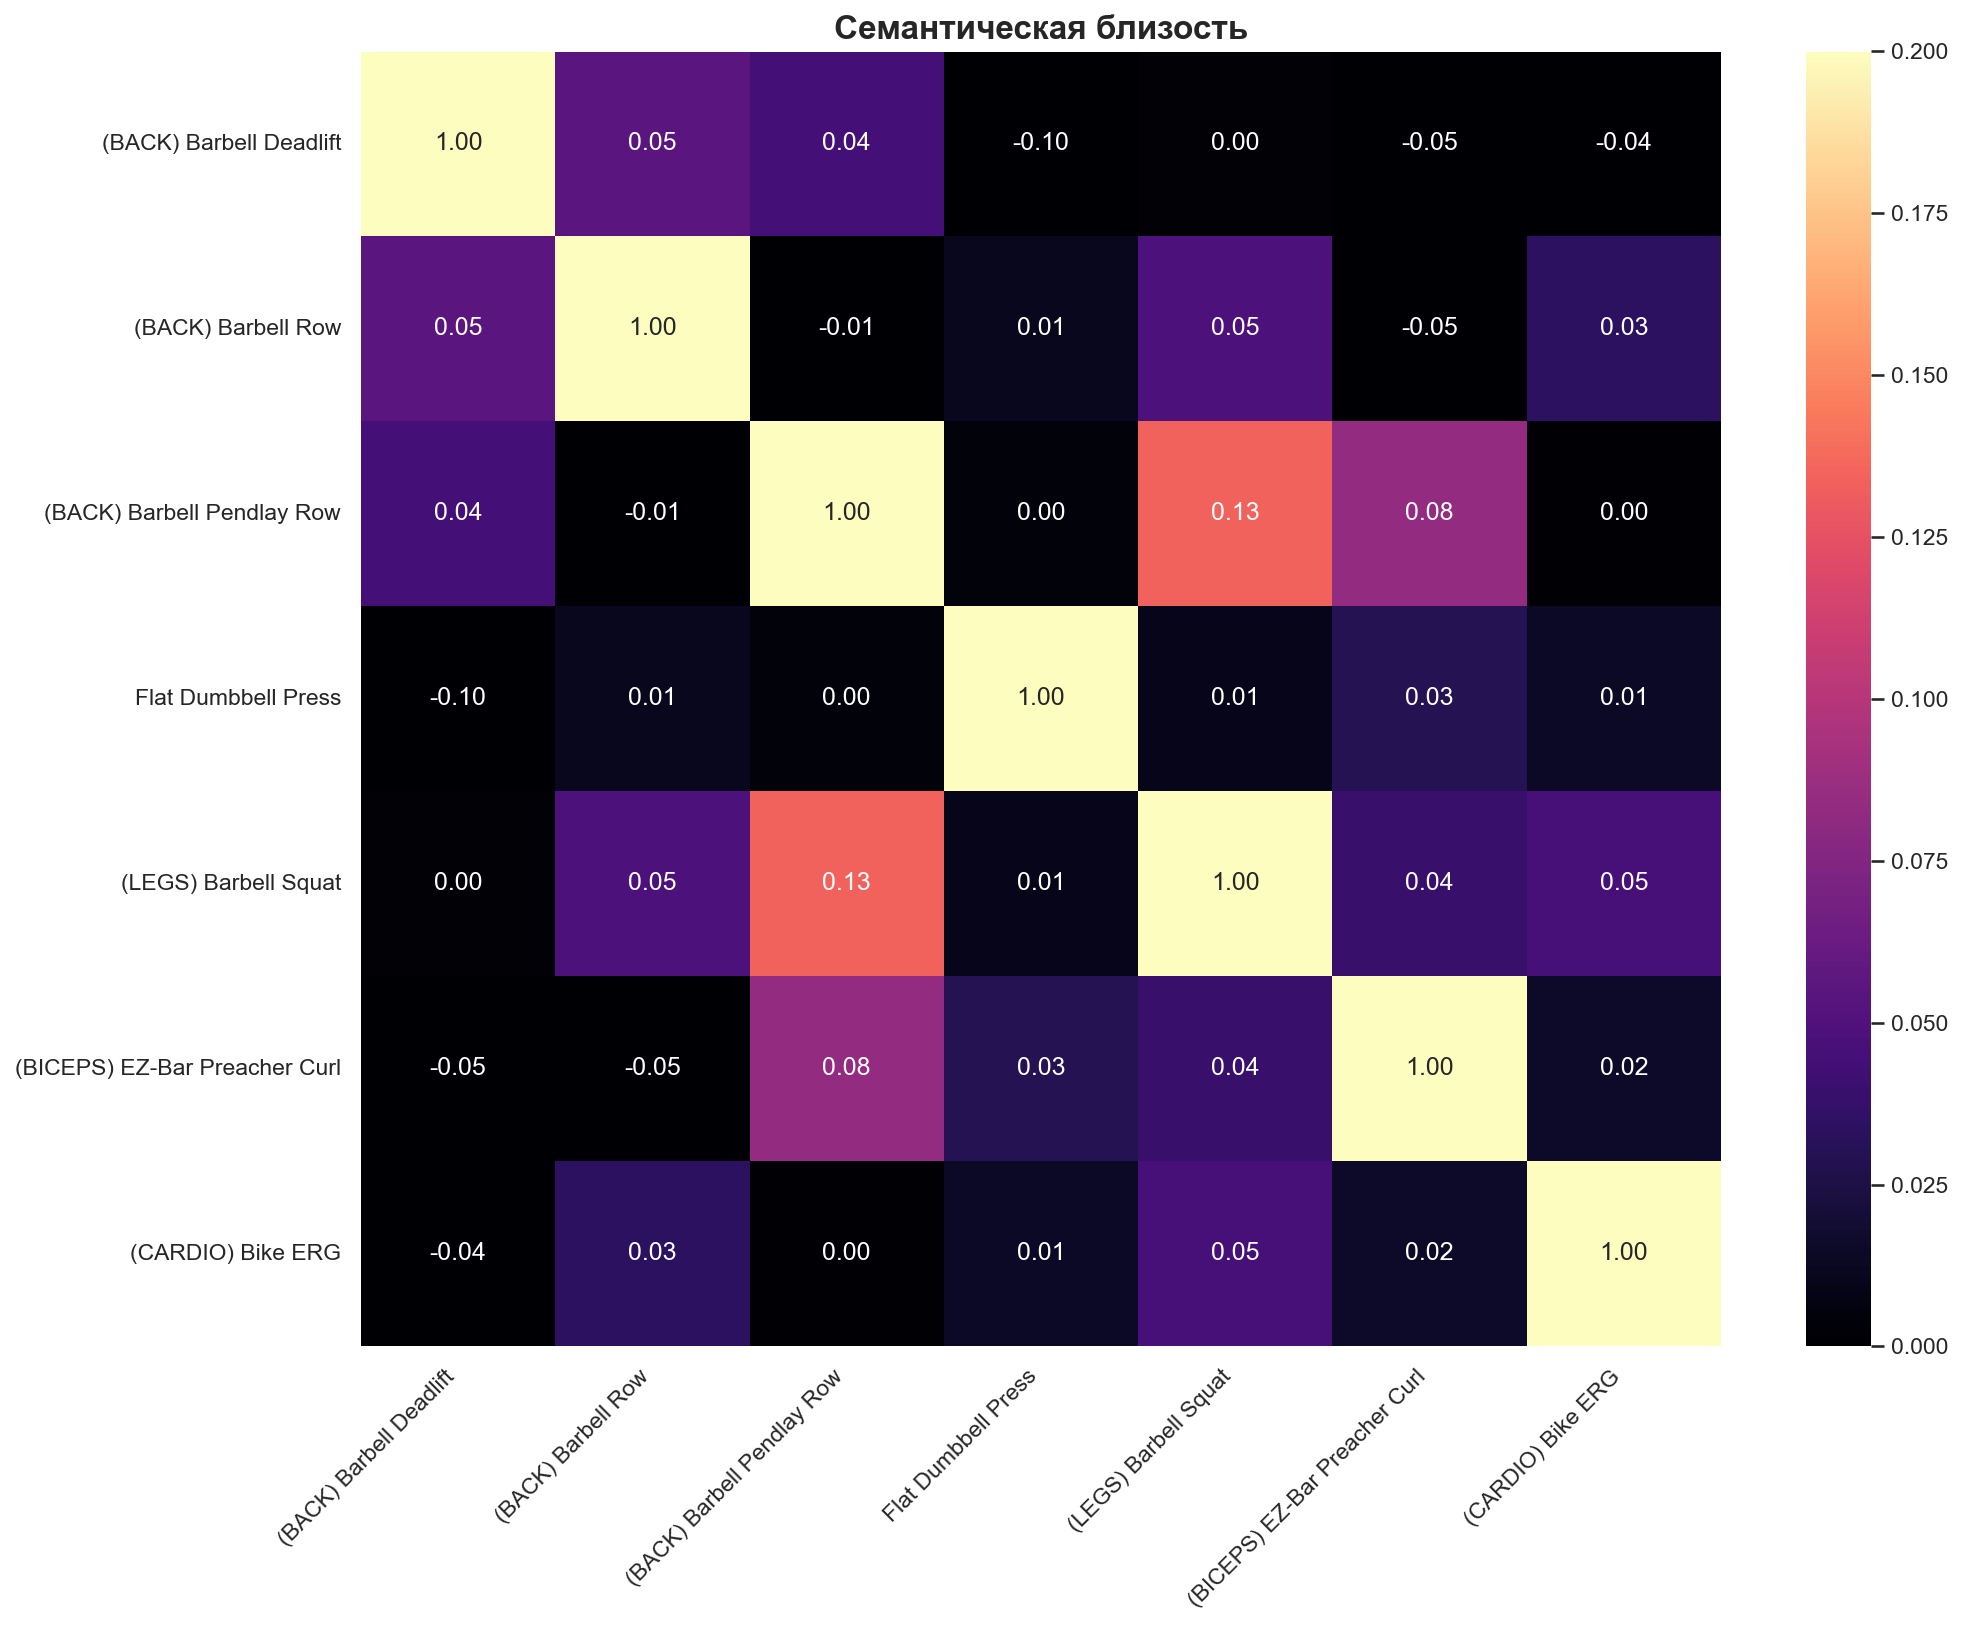

In [29]:
import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch
import json

# 1. Загружаем словарь (укажи правильный путь к своему vocab.json)
with open('../gym_model/vocab.json', 'r') as f:
    vocab = json.load(f)

# Обратный словарь для декодирования (ID -> Название)
id2token = {v: k for k, v in vocab.items()}
vocab_size = len(vocab)

class BERT4Rec(torch.nn.Module):
    def __init__(self, vocab_size, hidden=256, heads=8, layers=4, max_len=20):
        super().__init__()
        self.token_emb = torch.nn.Embedding(vocab_size, hidden)
        self.pos_emb = torch.nn.Embedding(max_len, hidden)
        encoder_layer = torch.nn.TransformerEncoderLayer(d_model=hidden, nhead=heads, batch_first=True)
        self.transformer = torch.nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.fc = torch.nn.Linear(hidden, vocab_size)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(positions)
        x = self.transformer(x)
        return self.fc(x)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = BERT4Rec(vocab_size).to(device)
model.load_state_dict(torch.load('../gym_model/checkpoints/gym_bert_v2_ep27_hit0.3522.pth', map_location=device))
model.eval()

import seaborn as sns
import torch.nn.functional as F
import matplotlib.pyplot as plt
# --- РУЧНОЙ СПИСОК ДЛЯ РАЗНОЦВЕТНОЙ КАРТЫ ---
# Берем несколько из твоего скриншота и добавляем контрастные
my_curated_list = [
    # СПИНА
    '(BACK) Barbell Deadlift',
    '(BACK) Barbell Row',
    '(BACK) Barbell Pendlay Row',
    
    # ГРУДЬ (Твои новые 3 упражнения)
    'Barbell Bench Press',
    'Flat Dumbbell Press',
    'Incline Barbell Bench Press',
    
    # НОГИ
    '(LEGS) Barbell Squat',
    '(LEGS) Leg Press',
    
    # РУКИ И КАРДИО
    '(BICEPS) EZ-Bar Preacher Curl',
    '(CARDIO) Bike ERG'
]

# Запуск функции (используй ту же plot_fancy_heatmap с vmax=0.2)


def plot_fancy_heatmap(model, vocab, target_list):
    # Фильтруем список, оставляя только те, что точно есть в твоем словаре
    final_selection = [ex for ex in target_list if ex in vocab]
    
    embeddings = model.token_emb.weight.data
    subset_ids = [vocab[name] for name in final_selection]
    subset_embeddings = embeddings[subset_ids]
    
    # Считаем косинусную близость
    similarity = F.cosine_similarity(subset_embeddings.unsqueeze(1), subset_embeddings.unsqueeze(0), dim=2)
    similarity = similarity.cpu().numpy()
    
    # --- ХАК ДЛЯ "ЦВЕТНОСТИ" ---
    # Если числа все еще маленькие, мы немного "растянем" контраст для визуала
    plt.figure(figsize=(14, 11))
    
    # Используем палитру 'rocket' или 'magma' с установленными границами
    # vmin и vmax заставляют даже небольшие отличия в 0.1-0.2 ярко светиться
    sns.heatmap(similarity, 
                xticklabels=final_selection, 
                yticklabels=final_selection, 
                annot=True, 
                fmt=".2f", 
                cmap='magma',
                vmin=0,   # Низ шкалы
                vmax=0.2) # Верх шкалы (всё что выше 0.2 будет ярко-желтым)
    
    plt.title('Семантическая близость', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Запуск
plot_fancy_heatmap(model, vocab, my_curated_list)